<a href="https://colab.research.google.com/github/fadeeva/portfoli_o_o_ptimisation/blob/main/Step_02__Classical_Markowitz%20_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import numpy as np
import pandas as pd

from scipy import optimize

import datetime as dt
import yfinance as yf

import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('ggplot')

In [11]:
rng = np.random.default_rng(42)

# Classical Markowitz optimization

In [12]:
tickers  = ['AMD', 'AMZN', 'BAC', 'META', 'AVGO', 'TER', 'NVDA']

df = yf.download(tickers, dt.datetime(2022, 1, 1), dt.datetime.now(), auto_adjust=True)
df = df['Close']
df = pd.concat([df, df.pct_change(fill_method=None).add_suffix('_simp_ret')], axis=1)
df.dropna(inplace=True)

df.head()

[*********************100%***********************]  7 of 7 completed


Ticker,AMD,AMZN,AVGO,BAC,META,NVDA,TER,AMD_simp_ret,AMZN_simp_ret,AVGO_simp_ret,BAC_simp_ret,META_simp_ret,NVDA_simp_ret,TER_simp_ret
Date,,,,,,,,,,,,,,
2022-01-04,144.419998,167.522003,62.018623,42.882717,333.600525,29.197760,163.409286,-0.038738,-0.016916,0.011457,0.039194,-0.005937,-0.027589,0.001625
2022-01-05,136.149994,164.356995,59.437752,42.158924,321.348053,27.517071,157.388687,-0.057264,-0.018893,-0.041614,-0.016878,-0.036728,-0.057562,-0.036844
2022-01-06,136.229996,163.253998,58.885887,43.007824,329.565887,28.089264,160.561050,0.000588,-0.006711,-0.009285,0.020136,0.025573,0.020794,0.020156
2022-01-07,132.000000,162.554001,57.233093,43.946072,328.901764,27.161196,155.444092,-0.031050,-0.004288,-0.028068,0.021816,-0.002015,-0.033040,-0.031869
2022-01-10,132.000000,161.485992,57.418907,43.722675,325.214081,27.313711,153.813736,0.000000,-0.006570,0.003247,-0.005083,-0.011212,0.005615,-0.010488


## Weighted Portfolio Return

In [13]:
amounts = rng.integers(low=10, high=50, size=len(tickers))

returns = df[[ticker+'_simp_ret' for ticker in tickers]]
returns.columns = tickers

position = df[tickers] * amounts
weights = position.div(position.sum(axis=1), axis=0)


portfolio_returns = (weights * returns).sum(axis=1)
portfolio_cummulative = (1 + portfolio_returns).cumprod() - 1

portfolio_cummulative.iloc[-1]

np.float64(2.4480395363508487)

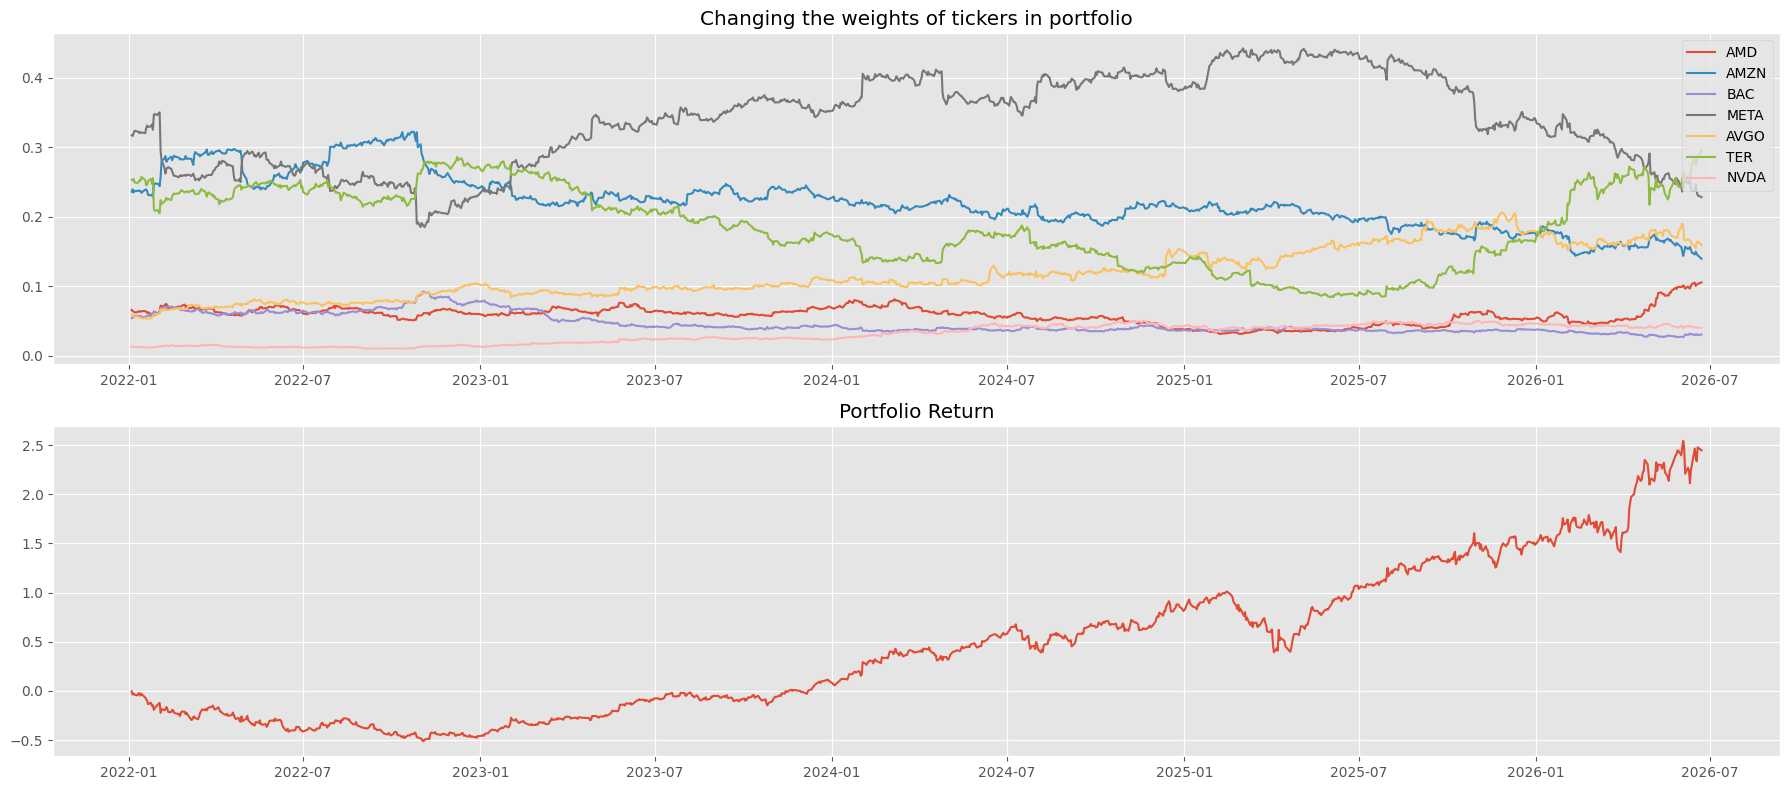

In [14]:
fig, axs = plt.subplots(2, 1, figsize=(18, 8))

axs[0].plot(weights, label=tickers)
axs[0].set_title('Changing the weights of tickers in portfolio')
axs[0].legend()

axs[1].plot(portfolio_cummulative)
axs[1].set_title('Portfolio Return')

plt.tight_layout()

## Portfolio risk

$
\sigma_p = \sqrt{w^T\Sigma w}
$

In [15]:
w = weights.iloc[-1].values
cov_matrix = returns.cov() * 252

portfolio_variance = w.T @ cov_matrix @ w
portfolio_risk = np.sqrt(portfolio_variance)

portfolio_risk

np.float64(0.36268429555957693)

In [16]:
risk_contributions = pd.DataFrame({
    'ticker': tickers,
    'weight': w,
    'volatility': np.sqrt(np.diag(cov_matrix)),
    'risk_contribution': w * np.sqrt(np.diag(cov_matrix))
})

risk_contributions['risk_share'] = risk_contributions['risk_contribution'] / portfolio_risk

risk_contributions

,ticker,weight,volatility,risk_contribution,risk_share
0,AMD,0.105859,0.570591,0.060402,0.166542
1,AMZN,0.139835,0.368038,0.051464,0.141899
2,BAC,0.030872,0.270125,0.008339,0.022993
3,META,0.228327,0.457191,0.104389,0.287824
4,AVGO,0.159455,0.454439,0.072463,0.199796
5,TER,0.295183,0.520977,0.153783,0.424014
6,NVDA,0.040470,0.524729,0.021236,0.058551


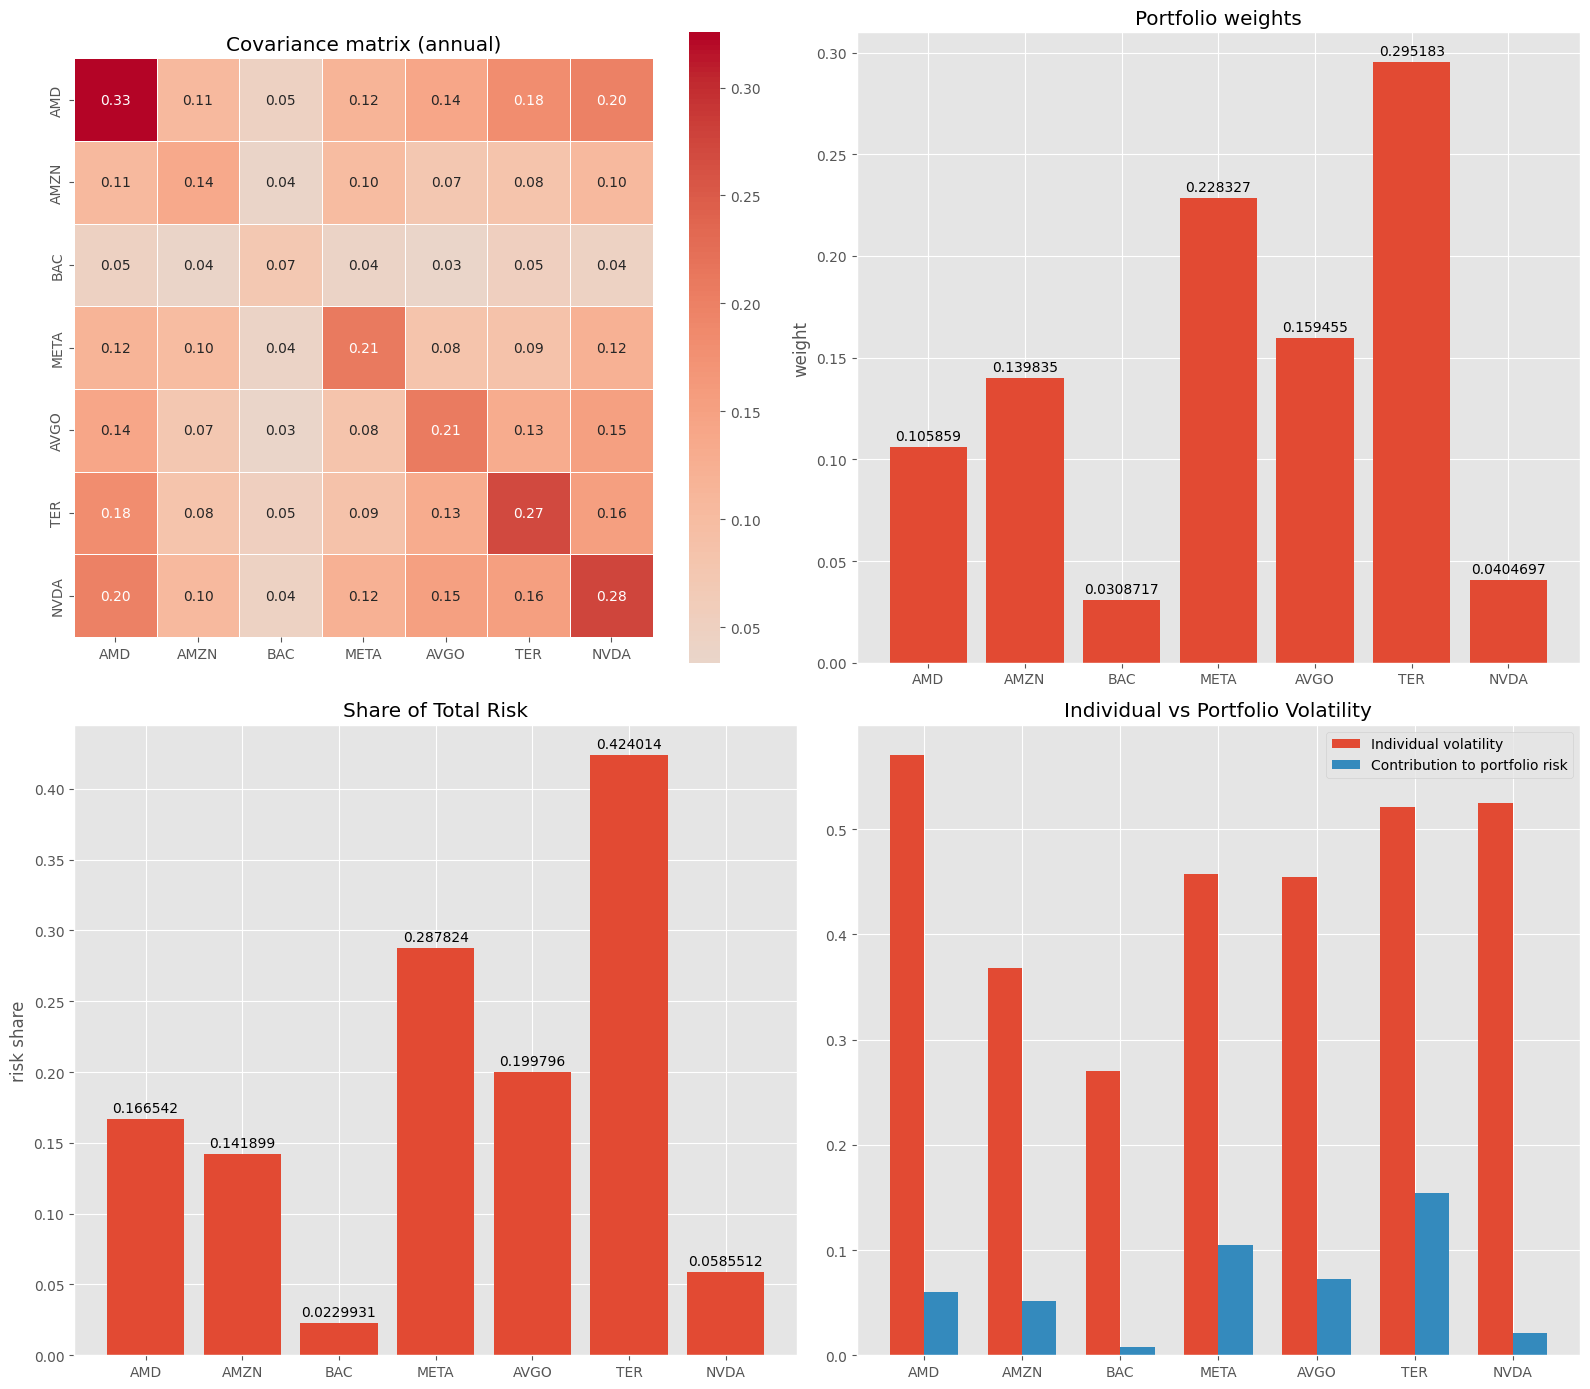

In [17]:
fig, axs = plt.subplots(2, 2, figsize=(16, 14))

sns.heatmap(
    cov_matrix, annot=True,
    cmap='coolwarm', center=0,
    fmt='.2f', square=True,
    linewidths=0.5, ax=axs[0, 0])\
    .set_title('Covariance matrix (annual)')

bars = axs[0, 1].bar(tickers, w)
axs[0, 1].bar_label(bars, padding=3)
axs[0, 1].set_title('Portfolio weights')
axs[0, 1].set_ylabel('weight')

bars = axs[1, 0].bar(tickers, risk_contributions['risk_share'])
axs[1, 0].bar_label(bars, padding=3)
axs[1, 0].set_title('Share of Total Risk')
axs[1, 0].set_ylabel('risk share')

x = np.arange(len(tickers))
width = 0.35
axs[1, 1].bar(x - width/2, risk_contributions['volatility'], width, label='Individual volatility')
axs[1, 1].bar(x + width/2, risk_contributions['risk_contribution'], width, label='Contribution to portfolio risk')
axs[1, 1].set_xticks(x)
axs[1, 1].set_xticklabels(tickers)
axs[1, 1].set_title('Individual vs Portfolio Volatility')
axs[1, 1].legend()

plt.tight_layout()


## Diversification Effect

In [23]:
avg_volatility = np.mean(np.sqrt(np.diag(cov_matrix)))
print(f'Average Asset Volatility: {avg_volatility:.2%}')
print(f'Portfolio Risk:           {portfolio_risk:.2%}')
print(f'Diversification Effect:   {(avg_volatility - portfolio_risk):.2%}')
print('*'*73)

# Why is the portfolio risk lower than average?
# Due to correlation between assets
corr_matrix = returns.corr()
corr_matrix

Average Asset Volatility: 45.23%
Portfolio Risk:           36.27%
Diversification Effect:   8.96%
*************************************************************************


,AMD,AMZN,BAC,META,AVGO,TER,NVDA
AMD,1.000000,0.500222,0.307094,0.447089,0.540817,0.609413,0.663957
AMZN,0.500222,1.000000,0.386870,0.604989,0.447111,0.425101,0.542484
BAC,0.307094,0.386870,1.000000,0.323593,0.273017,0.369306,0.310134
META,0.447089,0.604989,0.323593,1.000000,0.398495,0.363977,0.503115
AVGO,0.540817,0.447111,0.273017,0.398495,1.000000,0.559371,0.634702
TER,0.609413,0.425101,0.369306,0.363977,0.559371,1.000000,0.568195
NVDA,0.663957,0.542484,0.310134,0.503115,0.634702,0.568195,1.000000
